# Model Building

In this notebook, multiple machine learning algorithms are trained and compared to predict flight arrival delays.

The preprocessing pipeline developed in the previous notebook is integrated with each model to ensure consistent data transformations during training and evaluation.

The models are evaluated using the validation dataset (2022), while the test dataset (2023) is reserved for the final evaluation in the next notebook.

The following models will be implemented:

- Logistic Regression
- Random Forest
- XGBoost

Hyperparameter tuning will be performed to improve model performance, and the best-performing model will be selected for deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    TargetEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit
)

In [2]:
from pathlib import Path


def find_project_root() -> Path:
    """
    Locate the project root whether the notebook is launched
    from the project root or from inside the notebooks folder.
    """
    current_path = Path.cwd().resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from inside the "
        "Flight_Delay_Prediction project folder."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

RAW_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/omarzakzook/Desktop/Flight_Delay_Prediction


In [3]:
engineered_data_path = (
    PROCESSED_DATA_DIRECTORY
    / "engineered_flight_data.csv"
)

df = pd.read_csv(
    engineered_data_path,
    parse_dates=["FL_DATE"]
)

print("Loaded from:", engineered_data_path)
print("Dataset shape:", df.shape)
df.head()

Loaded from: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/data/processed/engineered_flight_data.csv
Dataset shape: (2913802, 30)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DAY_OF_WEEK,QUARTER,IS_WEEKEND,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,ROUTE,IS_PEAK_SEASON,IS_BUSY_HOUR
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,Wednesday,1,0,11,Morning,Winter,Medium,FLL_EWR,0,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,Saturday,4,1,21,Night,Autumn,Medium,MSP_SEA,1,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,Friday,3,0,9,Morning,Summer,Medium,DEN_MSP,1,1
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,Monday,1,0,16,Afternoon,Spring,Long,MSP_SFO,0,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,Sunday,1,1,18,Evening,Winter,Medium,MCO_DFW,0,1


In [4]:
selected_features = [

    "AIRLINE",

    "ORIGIN",
    "DEST",

    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "QUARTER",

    "DEP_HOUR",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"

]

target = "IS_DELAYED"

## Chronological Data Splitting

The dataset is divided chronologically:

- Training data: 2019–2021
- Validation data: 2022
- Test data: 2023

This approach preserves the temporal order of the data and provides a more realistic evaluation of future flight-delay predictions.

In [5]:
train_df = df[df["YEAR"] <= 2021].copy()

validation_df = df[df["YEAR"] == 2022].copy()

test_df = df[df["YEAR"] == 2023].copy()

In [6]:
X_train = train_df[selected_features]
y_train = train_df[target]

X_validation = validation_df[selected_features]
y_validation = validation_df[target]

In [7]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Temporal Holdout Test"
    ],
    "Period": [
        "2019–2021",
        "2022",
        "January–August 2023"
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ]
})

display(split_summary)

development_label_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "Delayed Flights": [
        int(y_train.sum()),
        int(y_validation.sum())
    ],
    "Delay Rate (%)": [
        y_train.mean() * 100,
        y_validation.mean() * 100
    ]
})

display(development_label_summary.round(2))

,Dataset,Period,Rows
0,Training,2019–2021,1791628
1,Validation,2022,667761
2,Temporal Holdout Test,January–August 2023,454413


,Dataset,Delayed Flights,Delay Rate (%)
0,Training,288736,16.12
1,Validation,140468,21.04


## Target Distribution

The target variable is imbalanced because on-time flights occur more frequently than delayed flights. Therefore, Accuracy is reported together with Precision, Recall, F1-score, and ROC-AUC.

In [8]:
class_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Proportion": y_train.value_counts(normalize=True)
}).rename(index={
    0: "On Time",
    1: "Delayed"
})

class_distribution

,Count,Proportion
IS_DELAYED,,
On Time,1502892,0.838842
Delayed,288736,0.161158


In [9]:
negative_class_count = int((y_train == 0).sum())
positive_class_count = int((y_train == 1).sum())

scale_pos_weight_value = (
    negative_class_count
    / positive_class_count
)

print("Training on-time flights:", negative_class_count)
print("Training delayed flights:", positive_class_count)
print(
    "XGBoost scale_pos_weight:",
    round(scale_pos_weight_value, 4)
)

Training on-time flights: 1502892
Training delayed flights: 288736
XGBoost scale_pos_weight: 5.2051


In [10]:
majority_baseline_accuracy = y_validation.value_counts(
    normalize=True
).max()

print(
    f"Majority-class baseline accuracy: "
    f"{majority_baseline_accuracy:.4f}"
)

Majority-class baseline accuracy: 0.7896


A classifier that predicts every validation flight as on time would achieve approximately 79.68% accuracy. Therefore, model accuracy must be interpreted relative to this baseline and alongside Recall and F1-score.

In [11]:
numerical_features = [

    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "QUARTER",

    "DEP_HOUR",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"

]

In [12]:
one_hot_features = [

    "DAY_OF_WEEK",

    "TIME_OF_DAY",

    "SEASON",

    "DISTANCE_CATEGORY"

]

In [13]:
target_encode_features = [

    "AIRLINE",

    "ORIGIN",

    "DEST"

]

In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [15]:
one_hot_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [16]:
target_transformer = Pipeline(
    steps=[
        (
            "target_encoder",
            TargetEncoder(
                target_type="binary",
                random_state=42
            )
        )
    ]
)

In [17]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "onehot",
            one_hot_transformer,
            one_hot_features
        ),

        (
            "target",
            target_transformer,
            target_encode_features
        )

    ],

    remainder="drop"

)

## Model Evaluation Function

To avoid repeating evaluation code for each machine learning model, a reusable function is created. This function computes the most common classification performance metrics and returns them in a structured format.

The evaluated metrics are:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics will be used consistently for comparing all models.

In [18]:
def evaluate_model(model, X, y, model_name="Model"):
    """
    Evaluate a classification model and display its performance metrics.
    """

    # Predictions
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # Metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_prob)

    # Results table
    results = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    })

    print(f"\n{'='*60}")
    print(f"{model_name} Performance")
    print(f"{'='*60}")

    display(results)

    print("\nClassification Report\n")
    print(classification_report(y, y_pred))

    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

## Logistic Regression

Logistic Regression is used as the baseline classification model. It provides a simple and interpretable benchmark against which more complex machine learning models can be compared.

The preprocessing steps and Logistic Regression classifier are combined into a single pipeline. This ensures that all transformations are learned only from the training data, which prevents data leakage.

In [19]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [20]:
print("Training Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Training Logistic Regression...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Logistic Regression training completed.



Logistic Regression Performance


,Metric,Score
0,Accuracy,0.667728
1,Precision,0.308066
2,Recall,0.465117
3,F1-Score,0.370641
4,ROC-AUC,0.635484



Classification Report

              precision    recall  f1-score   support

           0       0.84      0.72      0.77    527293
           1       0.31      0.47      0.37    140468

    accuracy                           0.67    667761
   macro avg       0.57      0.59      0.57    667761
weighted avg       0.72      0.67      0.69    667761



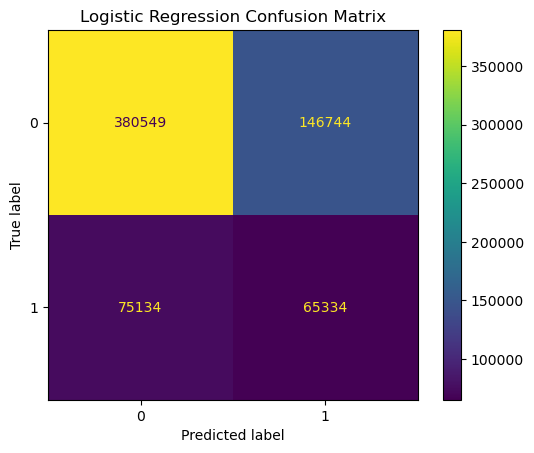

In [21]:
logistic_results = evaluate_model(
    model=logistic_pipeline,
    X=X_validation,
    y=y_validation,
    model_name="Logistic Regression"
)

## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to capture nonlinear relationships and feature interactions.

Because delayed flights represent the minority class, balanced class weights are used to give greater importance to delayed observations during training.

The same preprocessing pipeline is applied to maintain consistency across all models.

In [22]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
           RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [23]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Random Forest training completed.



Random Forest Performance


,Metric,Score
0,Accuracy,0.765808
1,Precision,0.367596
2,Recall,0.157288
3,F1-Score,0.220310
4,ROC-AUC,0.614041



Classification Report

              precision    recall  f1-score   support

           0       0.81      0.93      0.86    527293
           1       0.37      0.16      0.22    140468

    accuracy                           0.77    667761
   macro avg       0.59      0.54      0.54    667761
weighted avg       0.71      0.77      0.73    667761



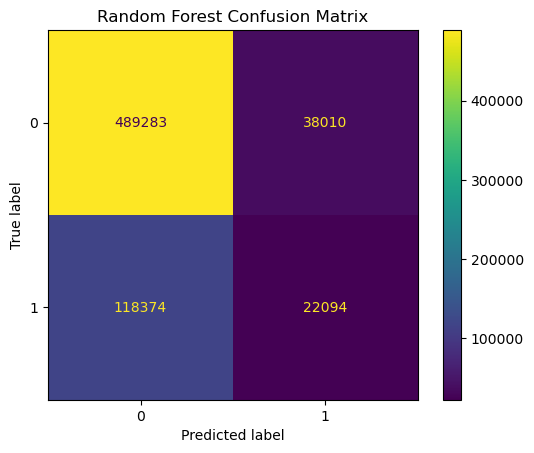

In [24]:
rf_results = evaluate_model(
    model=rf_pipeline,
    X=X_validation,
    y=y_validation,
    model_name="Random Forest"
)

## XGBoost

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting decision trees.

XGBoost builds trees sequentially, where each new tree corrects the errors made by the previous trees. It incorporates regularization techniques to reduce overfitting and often achieves state-of-the-art performance on structured datasets.

The same preprocessing pipeline is used to ensure a fair comparison with the previous models.

In [25]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight_value,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [26]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

Training XGBoost...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


XGBoost training completed.



XGBoost Performance


,Metric,Score
0,Accuracy,0.624893
1,Precision,0.291250
2,Recall,0.546359
3,F1-Score,0.379955
4,ROC-AUC,0.635310



Classification Report

              precision    recall  f1-score   support

           0       0.84      0.65      0.73    527293
           1       0.29      0.55      0.38    140468

    accuracy                           0.62    667761
   macro avg       0.57      0.60      0.56    667761
weighted avg       0.73      0.62      0.66    667761



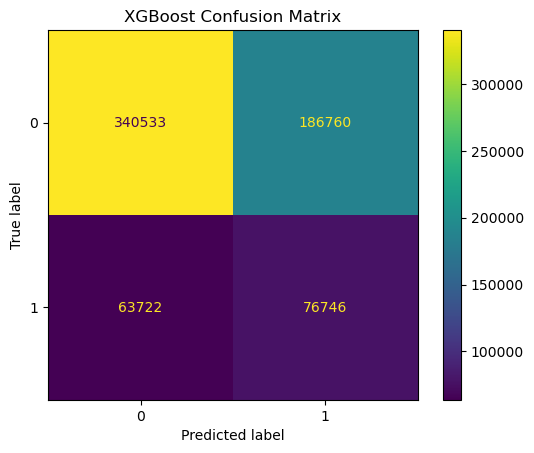

In [27]:
xgb_results = evaluate_model(
    model=xgb_pipeline,
    X=X_validation,
    y=y_validation,
    model_name="XGBoost"
)

In [28]:
comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

comparison.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.667728,0.308066,0.465117,0.370641,0.635484
1,XGBoost,0.624893,0.291250,0.546359,0.379955,0.635310
2,Random Forest,0.765808,0.367596,0.157288,0.220310,0.614041


The baseline models showed that the dataset suffers from class imbalance. Although Logistic Regression and XGBoost achieved higher accuracy, they identified very few delayed flights. Random Forest produced the highest Recall and F1-score but lower ROC-AUC. Therefore, further hyperparameter tuning and imbalance handling are required before selecting the final model.

## XGBoost Hyperparameter Tuning

XGBoost is selected for further tuning because it provides strong nonlinear modeling capability and probability-based predictions.

To respect the temporal structure of the flight data:

- The training records are ordered chronologically.
- A maximum of 400,000 observations is selected across the full training timeline.
- `TimeSeriesSplit` is used instead of ordinary random cross-validation.
- Multiple metrics are recorded.
- F1-score is used as the refitting criterion because the delayed class is the minority class and both precision and recall are important.

In [51]:
ordered_train_df = (
    train_df
    .sort_values("FL_DATE")
    .reset_index(drop=True)
)

tune_size = min(
    400_000,
    len(ordered_train_df)
)

sample_positions = np.linspace(
    0,
    len(ordered_train_df) - 1,
    tune_size,
    dtype=int
)

tune_df = (
    ordered_train_df
    .iloc[sample_positions]
    .copy()
)

X_tune = tune_df[selected_features]
y_tune = tune_df[target]

print("Tuning sample shape:")
print(X_tune.shape)

print("\nTuning date range:")
print(
    tune_df["FL_DATE"].min(),
    "to",
    tune_df["FL_DATE"].max()
)

print("\nClass proportions:")
print(
    y_tune
    .value_counts(normalize=True)
    .sort_index()
)

Tuning sample shape:
(400000, 19)

Tuning date range:
2019-01-01 00:00:00 to 2021-12-31 00:00:00

Class proportions:
IS_DELAYED
0    0.839893
1    0.160108
Name: proportion, dtype: float64


In [52]:
xgb_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                scale_pos_weight=scale_pos_weight_value,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [53]:
param_distributions = {
    "classifier__n_estimators": [150, 250, 350, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__min_child_weight": [1, 3, 5, 10],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_alpha": [0, 0.01, 0.1, 0.5],
    "classifier__reg_lambda": [1, 2, 5, 10]
}

In [54]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [55]:
temporal_cv = TimeSeriesSplit(
    n_splits=3
)

temporal_cv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)

In [56]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit="f1",
    cv=temporal_cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    return_train_score=False
)

In [57]:
print("Starting XGBoost hyperparameter tuning...")

xgb_random_search.fit(X_tune, y_tune)

print("Hyperparameter tuning completed.")

Starting XGBoost hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   1.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   1.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.05, classifier__max_depth=6, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.05, classifier__max_depth=6, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.05, classifier__max_depth=6, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   1.5s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   1.2s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.2s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   1.3s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.5, classifier__reg_lambda=10, classifier__subsample=0.7; total time=   1.6s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=150, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   0.6s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=150, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=150, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   0.8s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.9; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.5, classifier__reg_lambda=5, classifier__subsample=0.8; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.5, classifier__reg_lambda=5, classifier__subsample=0.8; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.5, classifier__reg_lambda=5, classifier__subsample=0.8; total time=   1.8s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   1.3s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0, classifier__reg_lambda=5, classifier__subsample=0.9; total time=   1.6s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   0.6s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=1, classifier__subsample=1.0; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=250, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.1, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   0.8s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.1, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.1, classifier__learning_rate=0.08, classifier__max_depth=4, classifier__min_child_weight=5, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=1, classifier__n_estimators=350, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=1, classifier__n_estimators=350, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.03, classifier__max_depth=3, classifier__min_child_weight=1, classifier__n_estimators=350, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   1.3s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=150, classifier__reg_alpha=0.5, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=150, classifier__reg_alpha=0.5, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.5, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=3, classifier__n_estimators=150, classifier__reg_alpha=0.5, classifier__reg_lambda=2, classifier__subsample=0.7; total time=   1.1s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.8; total time=   0.5s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.8; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.1, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0, classifier__reg_lambda=1, classifier__subsample=0.8; total time=   0.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.3s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.08, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=250, classifier__reg_alpha=0.01, classifier__reg_lambda=2, classifier__subsample=1.0; total time=   1.8s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=1.0; total time=   1.8s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=1.0; total time=   2.5s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.9, classifier__gamma=0.1, classifier__learning_rate=0.05, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=500, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=1.0; total time=   3.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.8; total time=   1.4s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.8; total time=   1.9s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0.5, classifier__learning_rate=0.1, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=350, classifier__reg_alpha=0.01, classifier__reg_lambda=10, classifier__subsample=0.8; total time=   2.3s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.8; total time=   0.5s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.8; total time=   0.7s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=4, classifier__min_child_weight=10, classifier__n_estimators=150, classifier__reg_alpha=0.1, classifier__reg_lambda=2, classifier__subsample=0.8; total time=   1.0s


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Hyperparameter tuning completed.


In [58]:
print("Best cross-validation F1-score:")
print(xgb_random_search.best_score_)

print("\nBest parameters:")
xgb_random_search.best_params_

Best cross-validation F1-score:
0.23258837198872725

Best parameters:


{'classifier__subsample': 0.9,
 'classifier__reg_lambda': 2,
 'classifier__reg_alpha': 0.1,
 'classifier__n_estimators': 250,
 'classifier__min_child_weight': 5,
 'classifier__max_depth': 6,
 'classifier__learning_rate': 0.08,
 'classifier__gamma': 0.3,
 'classifier__colsample_bytree': 0.7}

In [59]:
cv_results = pd.DataFrame(
    xgb_random_search.cv_results_
)

result_columns = [
    "rank_test_f1",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "params"
]

cv_results[
    result_columns
].sort_values(
    by="rank_test_f1"
).head(10)

,rank_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,params
7,1,0.697660,0.224465,0.352392,0.232588,0.605193,"{'classifier__subsample': 0.9, 'classifier__re..."
3,2,0.694877,0.218951,0.352151,0.229188,0.603399,"{'classifier__subsample': 0.9, 'classifier__re..."
5,3,0.687167,0.225672,0.359436,0.223293,0.607937,"{'classifier__subsample': 0.7, 'classifier__re..."
1,4,0.686433,0.225049,0.359544,0.222604,0.607063,"{'classifier__subsample': 1.0, 'classifier__re..."
4,5,0.690793,0.225505,0.350906,0.220575,0.604856,"{'classifier__subsample': 1.0, 'classifier__re..."
2,6,0.693917,0.227280,0.348299,0.219907,0.608499,"{'classifier__subsample': 0.7, 'classifier__re..."
12,7,0.677770,0.212908,0.365784,0.219812,0.602199,"{'classifier__subsample': 1.0, 'classifier__re..."
8,8,0.724270,0.227167,0.302864,0.218714,0.601458,"{'classifier__subsample': 0.8, 'classifier__re..."
16,9,0.713257,0.217419,0.310311,0.215043,0.592714,"{'classifier__subsample': 1.0, 'classifier__re..."
17,10,0.726850,0.227588,0.295151,0.213314,0.597749,"{'classifier__subsample': 1.0, 'classifier__re..."


In [60]:
best_xgb_params = {
    key.replace("classifier__", ""): value
    for key, value in xgb_random_search.best_params_.items()
}

best_xgb_params

{'subsample': 0.9,
 'reg_lambda': 2,
 'reg_alpha': 0.1,
 'n_estimators': 250,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.08,
 'gamma': 0.3,
 'colsample_bytree': 0.7}

In [61]:
tuned_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                **best_xgb_params,
                scale_pos_weight=scale_pos_weight_value,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [62]:
print("Training tuned XGBoost on the full training set...")

tuned_xgb_pipeline.fit(X_train, y_train)

print("Tuned XGBoost training completed.")

Training tuned XGBoost on the full training set...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Tuned XGBoost training completed.



Tuned XGBoost Performance


,Metric,Score
0,Accuracy,0.624253
1,Precision,0.291119
2,Recall,0.547890
3,F1-Score,0.380213
4,ROC-AUC,0.634871



Classification Report

              precision    recall  f1-score   support

           0       0.84      0.64      0.73    527293
           1       0.29      0.55      0.38    140468

    accuracy                           0.62    667761
   macro avg       0.57      0.60      0.56    667761
weighted avg       0.73      0.62      0.66    667761



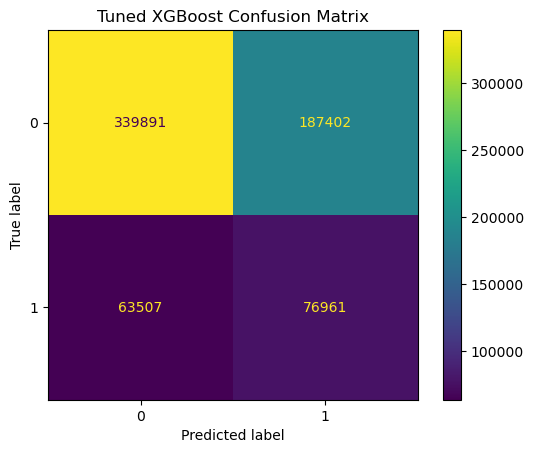

In [63]:
tuned_xgb_results = evaluate_model(
    model=tuned_xgb_pipeline,
    X=X_validation,
    y=y_validation,
    model_name="Tuned XGBoost"
)

In [64]:
comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results,
    tuned_xgb_results
])

comparison = (
    comparison
    .sort_values(
        by="F1",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Tuned XGBoost,0.624253,0.291119,0.547890,0.380213,0.634871
1,XGBoost,0.624893,0.291250,0.546359,0.379955,0.635310
2,Logistic Regression,0.667728,0.308066,0.465117,0.370641,0.635484
3,Random Forest,0.765808,0.367596,0.157288,0.220310,0.614041


In [65]:
xgb_tuning_change = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline XGBoost": [
        xgb_results["Accuracy"],
        xgb_results["Precision"],
        xgb_results["Recall"],
        xgb_results["F1"],
        xgb_results["ROC_AUC"]
    ],
    "Tuned XGBoost": [
        tuned_xgb_results["Accuracy"],
        tuned_xgb_results["Precision"],
        tuned_xgb_results["Recall"],
        tuned_xgb_results["F1"],
        tuned_xgb_results["ROC_AUC"]
    ]
})

xgb_tuning_change["Change"] = (
    xgb_tuning_change["Tuned XGBoost"]
    - xgb_tuning_change["Baseline XGBoost"]
)

xgb_tuning_change

,Metric,Baseline XGBoost,Tuned XGBoost,Change
0,Accuracy,0.624893,0.624253,-0.000639
1,Precision,0.291250,0.291119,-0.000131
2,Recall,0.546359,0.547890,0.001531
3,F1,0.379955,0.380213,0.000258
4,ROC-AUC,0.635310,0.634871,-0.000439


In [66]:
comparison["Accuracy_Above_Majority_Baseline"] = (
    comparison["Accuracy"] - majority_baseline_accuracy
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Accuracy_Above_Majority_Baseline
0,Tuned XGBoost,0.624253,0.291119,0.547890,0.380213,0.634871,-0.165390
1,XGBoost,0.624893,0.291250,0.546359,0.379955,0.635310,-0.164751
2,Logistic Regression,0.667728,0.308066,0.465117,0.370641,0.635484,-0.121915
3,Random Forest,0.765808,0.367596,0.157288,0.220310,0.614041,-0.023835


In [67]:
(y_validation == 0).mean()

np.float64(0.7896433005221928)

## Model Building Conclusion

Logistic Regression, Random Forest, baseline XGBoost, and temporally tuned XGBoost were evaluated using the 2022 validation period.

The validation results showed different trade-offs:

- Random Forest achieved the highest accuracy, but its accuracy remained below the majority-class baseline and it detected relatively few delayed flights.
- Logistic Regression achieved the highest ROC-AUC by a small margin.
- Baseline XGBoost achieved the highest delayed-flight recall and almost the highest F1-score.
- Temporally tuned XGBoost produced only a very small F1 improvement over baseline XGBoost, with almost no meaningful change in the remaining metrics.

The tuning process used a chronologically distributed training sample, `TimeSeriesSplit`, and F1-score as the refitting criterion. The relatively low temporal cross-validation F1-score indicates that model performance varies across time periods and that temporal distribution shift is an important limitation.

Overall, the existing pre-departure features provide limited predictive signal. Hyperparameter tuning alone did not materially improve performance. Therefore, the next notebook evaluates an explicitly different prediction scenario using information available immediately after departure, particularly actual departure time and departure delay.

The January–August 2023 temporal holdout was not used for model fitting, hyperparameter tuning, threshold selection, or model comparison. It will be scored by the frozen final pipeline in Notebook 9.